# Decision Tree Classification for Predicting CS-SINS scores of IgG1 antibodies

Author: Hsin-Ting Chen

Objective: The goal of this notebook is to use support vector regression to predict whether an IgG1 Fv region has high or low CS-SINS score.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
import joblib

In [2]:
# Add path to training and testing data here
X_train = pd.read_csv('train_x.csv')
y_train = pd.read_csv('train_y.csv')['CS-SINS Label']
X_test = pd.read_csv('test_x.csv')
y_test = pd.read_csv('test_y.csv')['CS-SINS Label']

In [3]:
# get training and testing features
train_feat = X_train[['app_charge', 'zquadrupole']]
test_feat = X_test[['app_charge', 'zquadrupole']]

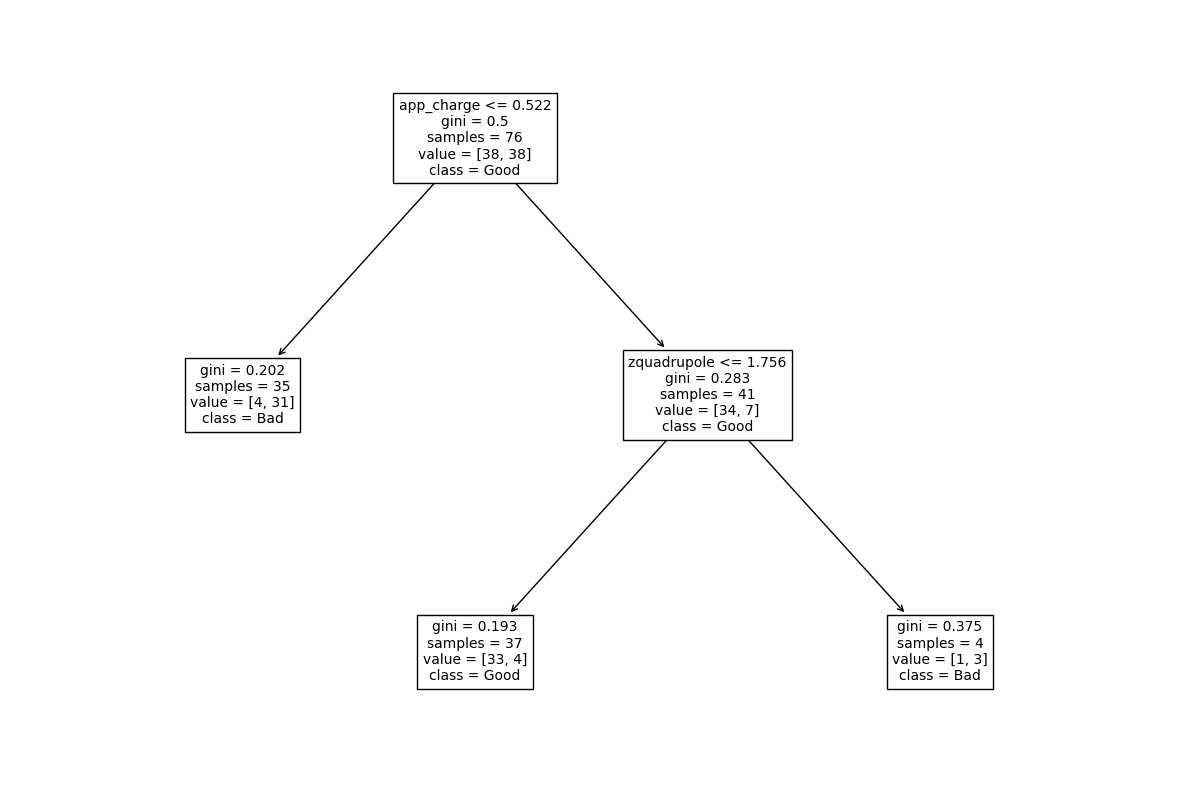

In [4]:
# load model
clf = joblib.load('CSSINS_Classifier.pkl')
plt.figure(figsize = (15,10));
plot_tree(clf, feature_names = train_feat.columns,class_names=["Good","Bad"], fontsize = 10);

In [5]:
# Evaluate the Training Dataset
ph6_predict = pd.DataFrame(clf.predict(train_feat))
print("Training Dataset Metrics")
print("Accuracy:", f"{accuracy_score(ph6_predict, y_train):1.2f}")
print("Balanced Accuracy:", f"{balanced_accuracy_score(y_train,ph6_predict):1.2f}")
print("Precision:", f"{precision_score(y_train,ph6_predict.iloc[:,0],pos_label=1):1.2f}")
print("Recall:", f"{recall_score(y_train,ph6_predict.iloc[:,0],pos_label=1):1.2f}")
print("F1 Score:", f"{f1_score(y_train,ph6_predict.iloc[:,0],pos_label=1):1.2f}")

Training Dataset Metrics
Accuracy: 0.88
Balanced Accuracy: 0.88
Precision: 0.87
Recall: 0.89
F1 Score: 0.88


In [6]:
# Evaluate the Testing Dataset
ph6_predict = pd.DataFrame(clf.predict(test_feat))
print("Testing Dataset Metrics")
print("Accuracy:", f"{accuracy_score(ph6_predict, y_test):1.2f}")
print("Balanced Accuracy:", f"{balanced_accuracy_score(y_test,ph6_predict):1.2f}")
print("Precision:", f"{precision_score(y_test,ph6_predict.iloc[:,0],pos_label=1):1.2f}")
print("Recall:", f"{recall_score(y_test,ph6_predict.iloc[:,0],pos_label=1):1.2f}")
print("F1 Score:", f"{f1_score(y_test,ph6_predict.iloc[:,0],pos_label=1):1.2f}")

Testing Dataset Metrics
Accuracy: 0.79
Balanced Accuracy: 0.79
Precision: 0.73
Recall: 0.89
F1 Score: 0.80


In [7]:
# Evaluate the Entire Dataset
X = pd.concat([train_feat, test_feat])
y = pd.concat([y_train, y_test])
ph6_predict = pd.DataFrame(clf.predict(X))
print("Entire Dataset Metrics")
print("Accuracy:", f"{accuracy_score(ph6_predict, y):1.2f}")
print("Balanced Accuracy:", f"{balanced_accuracy_score(y,ph6_predict):1.2f}")
print("Precision:", f"{precision_score(y,ph6_predict.iloc[:,0],pos_label=1):1.2f}")
print("Recall:", f"{recall_score(y,ph6_predict.iloc[:,0],pos_label=1):1.2f}")
print("F1 Score:", f"{f1_score(y,ph6_predict.iloc[:,0],pos_label=1):1.2f}")

Entire Dataset Metrics
Accuracy: 0.86
Balanced Accuracy: 0.86
Precision: 0.84
Recall: 0.89
F1 Score: 0.87
